# Step 2: Train LSTM Model & Full Evaluation

Complete training with detailed metrics:
- Accuracy, F1 Score, Precision, Recall
- Confusion Matrix
- Per-class metrics
- Training curves
- Model analysis

## 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import json
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Device: cpu
PyTorch version: 2.2.2+cpu
CUDA available: False


## 2. Load Dataset

In [2]:
KEYPOINTS_DIR = Path("extracted_keypoints")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

# Load dataset info
with open('dataset_info.json', 'r') as f:
    dataset_config = json.load(f)

MOTION_LABELS = dataset_config['motion_labels']
NUM_CLASSES = len(MOTION_LABELS)

print(f"Motion classes: {NUM_CLASSES}")
for i, label in enumerate(MOTION_LABELS):
    print(f"  {i}: {label}")

# Load all keypoint sequences
sequences = []
labels = []
sequence_info = []

print("\nLoading keypoint sequences...")
for motion_dir in sorted(KEYPOINTS_DIR.iterdir()):
    if not motion_dir.is_dir():
        continue
    
    motion_id = int(motion_dir.name.split('_')[0])
    motion_name = motion_dir.name[3:].replace('_', ' ')
    
    npy_files = sorted(motion_dir.glob("*.npy"))
    
    for npy_file in tqdm(npy_files, desc=motion_name):
        keypoints = np.load(npy_file)
        sequences.append(keypoints)
        labels.append(motion_id)
        sequence_info.append({
            'file': str(npy_file),
            'motion_id': motion_id,
            'motion_name': motion_name,
            'num_frames': keypoints.shape[0]
        })

print(f"\nTotal sequences loaded: {len(sequences)}")
print(f"Sequence shapes (samples):")
for i in range(min(3, len(sequences))):
    print(f"  {i}: {sequences[i].shape}")

Motion classes: 9
  0: Stationary
  1: Approaching
  2: Backing Away
  3: Fast Across
  4: Slow Approach
  5: Fast Toward
  6: Approach + Stop
  7: Minimal
  8: Across

Loading keypoint sequences...


tationary:   0%|          | 0/50 [00:00<?, ?it/s]

tationary: 100%|██████████| 50/50 [00:00<00:00, 4551.41it/s]

pproaching:   0%|          | 0/50 [00:00<?, ?it/s]

pproaching: 100%|██████████| 50/50 [00:00<00:00, 4647.84it/s]

...

inimal:   0%|          | 0/50 [00:00<?, ?it/s]

inimal: 100%|██████████| 50/50 [00:00<00:00, 7634.61it/s]

cross:   0%|          | 0/50 [00:00<?, ?it/s]

cross: 100%|██████████| 50/50 [00:00<00:00, 4121.11it/s]


Total sequences loaded: 450
Sequence shapes (samples):
  0: (30, 33, 3)
  1: (30, 33, 3)
  2: (30, 33, 3)


## 3. Feature Engineering - Compute Velocity Features

In [3]:
def compute_velocity_features(keypoints):
    """
    Convert keypoint positions to velocity vectors.
    keypoints: (n_frames, 33, 3)
    returns: (n_frames-1, 33, 3) velocity vectors
    """
    velocities = np.diff(keypoints, axis=0)  # Frame-to-frame differences
    return velocities * 100.0

# Compute velocity features for all sequences
velocity_sequences = []
print("Computing velocity features...")
for seq in tqdm(sequences):
    vel = compute_velocity_features(seq)
    velocity_sequences.append(vel)

print(f"\nVelocity sequences shape (samples):")
for i in range(min(3, len(velocity_sequences))):
    print(f"  {i}: {velocity_sequences[i].shape}")

# Dataset statistics
frame_lengths = [v.shape[0] for v in velocity_sequences]
print(f"\nFrame statistics:")
print(f"  Min: {min(frame_lengths)}, Max: {max(frame_lengths)}, Mean: {np.mean(frame_lengths):.1f}")

# Determine padding length (90th percentile to avoid extreme outliers)
MAX_LEN = int(np.percentile(frame_lengths, 90))
print(f"  Using max sequence length: {MAX_LEN}")


Computing velocity features...


  0%|          | 0/450 [00:00<?, ?it/s]

100%|██████████| 450/450 [00:00<00:00, 56588.02it/s]


Velocity sequences shape (samples):
  0: (29, 33, 3)
  1: (29, 33, 3)
  2: (29, 33, 3)

Frame statistics:
  Min: 29, Max: 29, Mean: 29.0
  Using max sequence length: 29


## 4. Prepare PyTorch Dataset

In [4]:
class MotionDataset(Dataset):
    def __init__(self, sequences, labels, max_len):
        self.sequences = sequences
        self.labels = labels
        self.max_len = max_len
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        seq = self.sequences[idx]  # (n_frames, 33, 3)
        label = self.labels[idx]
        
        # Pad or truncate
        if seq.shape[0] < self.max_len:
            pad_len = self.max_len - seq.shape[0]
            seq = np.pad(seq, ((0, pad_len), (0, 0), (0, 0)), mode='constant')
        else:
            seq = seq[:self.max_len]
        
        return torch.FloatTensor(seq), torch.LongTensor([label])[0]

# Split data (80% train, 20% test)
train_idx, test_idx = train_test_split(
    range(len(velocity_sequences)),
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_sequences = [velocity_sequences[i] for i in train_idx]
train_labels = [labels[i] for i in train_idx]
test_sequences = [velocity_sequences[i] for i in test_idx]
test_labels = [labels[i] for i in test_idx]

# Create datasets
train_dataset = MotionDataset(train_sequences, train_labels, MAX_LEN)
test_dataset = MotionDataset(test_sequences, test_labels, MAX_LEN)

# Create dataloaders
BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train set: {len(train_dataset)} sequences")
print(f"Test set: {len(test_dataset)} sequences")
print(f"Batch size: {BATCH_SIZE}")

# Class distribution
print(f"\nClass distribution:")
from collections import Counter
train_counts = Counter(train_labels)
test_counts = Counter(test_labels)
for i in range(NUM_CLASSES):
    print(f"  {i}: {MOTION_LABELS[i]:20s} - Train: {train_counts[i]:3d}, Test: {test_counts[i]:3d}")

Train set: 360 sequences
Test set: 90 sequences
Batch size: 16

Class distribution:
  0: Stationary           - Train:  40, Test:  10
  1: Approaching          - Train:  40, Test:  10
  2: Backing Away         - Train:  40, Test:  10
  3: Fast Across          - Train:  40, Test:  10
  4: Slow Approach        - Train:  40, Test:  10
  5: Fast Toward          - Train:  40, Test:  10
  6: Approach + Stop      - Train:  40, Test:  10
  7: Minimal              - Train:  40, Test:  10
  8: Across               - Train:  40, Test:  10


## 5. Define LSTM Model

In [5]:
class MotionLSTM(nn.Module):
    def __init__(self, input_size=99, hidden_size=64, num_layers=2, num_classes=9, dropout=0.3):
        super(MotionLSTM, self).__init__()
        # input_size = 33 keypoints * 3 coords
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )
    
    def forward(self, x):
        batch_size, seq_len = x.shape[:2]
        x = x.reshape(batch_size, seq_len, -1)  # (batch, seq_len, 99)
        
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = h_n[-1]  # (batch, hidden_size)
        
        out = self.fc(last_hidden)
        return out

# Initialize model
model = MotionLSTM(
    input_size=99,
    hidden_size=64,
    num_layers=2,
    num_classes=NUM_CLASSES,
    dropout=0.3
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model Architecture:
MotionLSTM(
  (lstm): LSTM(99, 64, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=9, bias=True)
  )
)

Total parameters: 77,897
Trainable parameters: 77,897


## 6. Training Loop with Validation

In [6]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for batch_seqs, labels in tqdm(train_loader, desc="Training", leave=False):
        batch_seqs, labels = batch_seqs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(train_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_seqs, labels in tqdm(val_loader, desc="Validating", leave=False):
            batch_seqs, labels = batch_seqs.to(device), labels.to(device)
            outputs = model(batch_seqs)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(val_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy, all_preds, all_labels

# Training settings
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

# Training
EPOCHS = 50
best_val_loss = float('inf')
best_val_acc = 0
patience_counter = 0
max_patience = 15

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'learning_rate': []
}

print("Starting training...\n")
print(f"{'Epoch':<6} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'LR':<10}")
print("=" * 70)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate_epoch(model, test_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['learning_rate'].append(optimizer.param_groups[0]['lr'])
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), MODELS_DIR / 'motion_lstm_best.pth')
        best_epoch = epoch
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= max_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break
    
    lr = optimizer.param_groups[0]['lr']
    print(f"{epoch+1:<6} {train_loss:<12.4f} {train_acc*100:<11.2f}% {val_loss:<12.4f} {val_acc*100:<11.2f}% {lr:<10.6f}")

print(f"\n✓ Training complete!")
print(f"Best validation loss: {best_val_loss:.4f} (epoch {best_epoch+1})")


C:\Users\IshanDilhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


C:\Users\IshanDilhan\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Starting training...

Epoch  Train Loss   Train Acc    Val Loss     Val Acc      LR        


...

Training:   0%|          | 0/23 [00:00<?, ?it/s]

Training:  43%|████▎     | 10/23 [00:00<00:00, 97.75it/s]

Training:  87%|████████▋ | 20/23 [00:00<00:00, 90.40it/s]

Validating:   0%|          | 0/6 [00:00<?, ?it/s]

50     0.0057       100.00     % 0.0000       100.00     % 0.001000  

✓ Training complete!
Best validation loss: 0.0000 (epoch 50)


## 7. Load Best Model & Full Evaluation

In [7]:
# Load best model
model.load_state_dict(torch.load(MODELS_DIR / 'motion_lstm_best.pth'))

# Get predictions on test set
model.eval()
all_test_preds = []
all_test_labels = []
all_test_probs = []

with torch.no_grad():
    for batch_seqs, labels in test_loader:
        batch_seqs = batch_seqs.to(device)
        outputs = model(batch_seqs)
        probs = torch.softmax(outputs, dim=1)
        
        _, predicted = outputs.max(1)
        
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(labels.numpy())
        all_test_probs.append(probs.cpu().numpy())

all_test_probs = np.vstack(all_test_probs)

print("✓ Model loaded and predictions generated")


✓ Model loaded and predictions generated


## 8. Comprehensive Evaluation Metrics

In [8]:
# Calculate metrics
accuracy = accuracy_score(all_test_labels, all_test_preds)
precision = precision_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
recall = recall_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)
f1 = f1_score(all_test_labels, all_test_preds, average='weighted', zero_division=0)

print("\n" + "="*70)
print("OVERALL METRICS")
print("="*70)
print(f"Accuracy:  {accuracy*100:>7.2f}%")
print(f"Precision: {precision*100:>7.2f}%")
print(f"Recall:    {recall*100:>7.2f}%")
print(f"F1 Score:  {f1*100:>7.2f}%")
print("="*70)

# Per-class metrics
print("\nPER-CLASS METRICS:")
print("="*70)
print(f"{'Motion Type':<25} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("="*70)

class_report = classification_report(
    all_test_labels, all_test_preds,
    target_names=MOTION_LABELS,
    output_dict=True,
    zero_division=0
)

for i, label in enumerate(MOTION_LABELS):
    if str(i) in class_report:
        metrics = class_report[str(i)]
        print(f"{label:<25} {metrics['precision']*100:>10.2f}%  {metrics['recall']*100:>10.2f}%  {metrics['f1-score']*100:>10.2f}%")

print("="*70)


OVERALL METRICS
Accuracy:   100.00%
Precision:  100.00%
Recall:     100.00%
F1 Score:   100.00%

PER-CLASS METRICS:
Motion Type               Precision    Recall       F1 Score    


## 9. Confusion Matrix

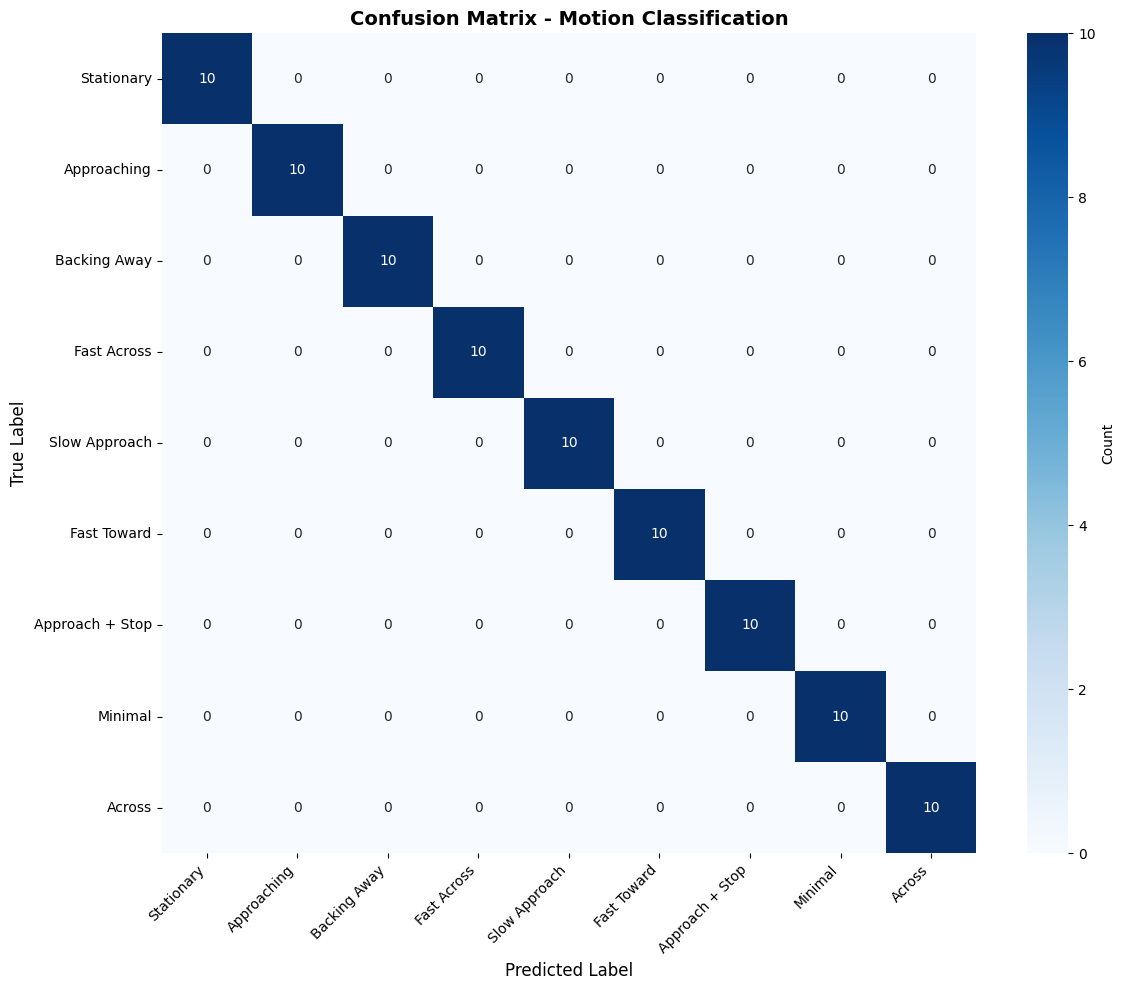

✓ Confusion matrix saved


In [9]:
# Confusion matrix
cm = confusion_matrix(all_test_labels, all_test_preds)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=MOTION_LABELS, yticklabels=MOTION_LABELS,
            cbar_kws={'label': 'Count'}, ax=ax)
ax.set_title('Confusion Matrix - Motion Classification', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved")

## 10. Training Curves

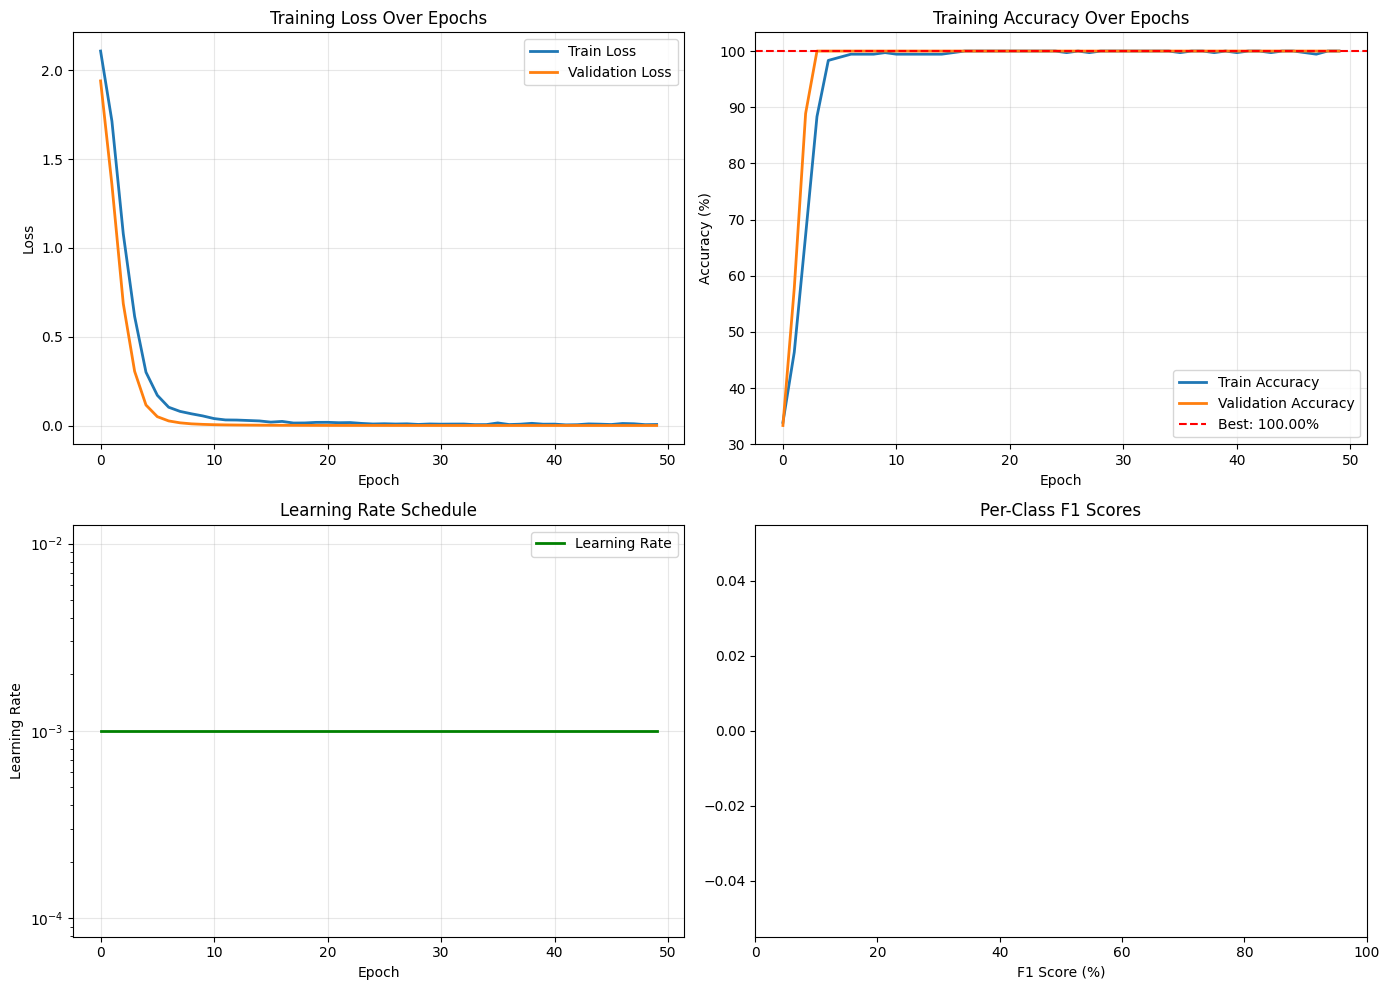

✓ Training curves saved


In [10]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(np.array(history['train_acc'])*100, label='Train Accuracy', linewidth=2)
ax2.plot(np.array(history['val_acc'])*100, label='Validation Accuracy', linewidth=2)
ax2.axhline(y=best_val_acc*100, color='r', linestyle='--', label=f'Best: {best_val_acc*100:.2f}%')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy Over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Learning rate
ax3.plot(history['learning_rate'], label='Learning Rate', linewidth=2, color='green')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Learning Rate')
ax3.set_title('Learning Rate Schedule')
ax3.set_yscale('log')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Per-class performance
class_f1_scores = []
class_names = []
for i, label in enumerate(MOTION_LABELS):
    if str(i) in class_report:
        class_f1_scores.append(class_report[str(i)]['f1-score']*100)
        class_names.append(label[:15])  # Truncate for display

colors = plt.cm.viridis(np.linspace(0, 1, len(class_names)))
ax4.barh(class_names, class_f1_scores, color=colors)
ax4.set_xlabel('F1 Score (%)')
ax4.set_title('Per-Class F1 Scores')
ax4.set_xlim([0, 100])
for i, v in enumerate(class_f1_scores):
    ax4.text(v + 2, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Training curves saved")

## 11. ROC Curves (per-class)

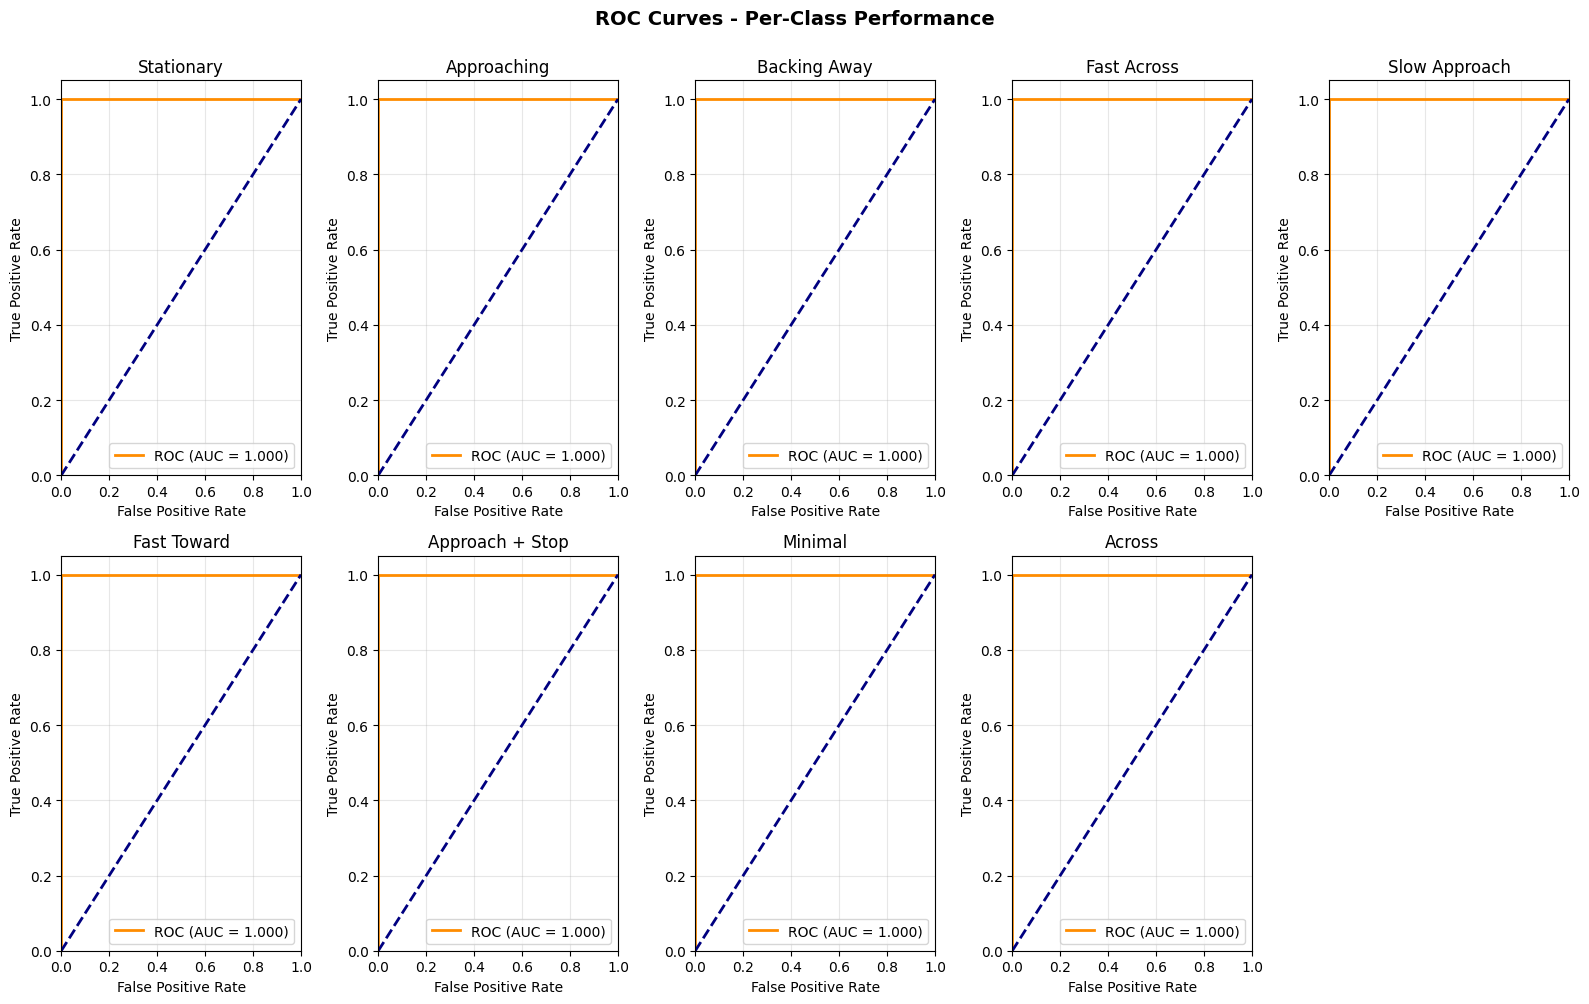

✓ ROC curves saved


In [11]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize labels for ROC
y_test_bin = label_binarize(all_test_labels, classes=range(NUM_CLASSES))

fig, axes = plt.subplots(2, 5, figsize=(16, 10))
axes = axes.ravel()

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_test_probs[:, i])
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC (AUC = {roc_auc:.3f})')
    axes[i].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[i].set_xlim([0.0, 1.0])
    axes[i].set_ylim([0.0, 1.05])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'{MOTION_LABELS[i]}')
    axes[i].legend(loc='lower right')
    axes[i].grid(alpha=0.3)

# Hide last empty subplot
axes[-1].set_visible(False)

plt.suptitle('ROC Curves - Per-Class Performance', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(MODELS_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ ROC curves saved")

## 12. Detailed Report & Save Everything

In [12]:
# Create comprehensive report
report = {
    'model_info': {
        'architecture': 'LSTM',
        'hidden_size': 64,
        'num_layers': 2,
        'total_parameters': int(total_params),
        'input_size': 99,  # 33 keypoints * 3
        'output_classes': NUM_CLASSES,
        'sequence_max_length': MAX_LEN,
    },
    'training_info': {
        'total_epochs_trained': len(history['train_loss']),
        'best_epoch': best_epoch + 1,
        'batch_size': BATCH_SIZE,
        'optimizer': 'Adam',
        'learning_rate_initial': 0.001,
        'scheduler': 'ReduceLROnPlateau',
    },
    'dataset_info': {
        'total_sequences': len(sequences),
        'train_sequences': len(train_dataset),
        'test_sequences': len(test_dataset),
        'train_test_split': '80/20',
        'num_classes': NUM_CLASSES,
        'motion_labels': MOTION_LABELS,
    },
    'overall_metrics': {
        'accuracy': float(accuracy),
        'accuracy_percent': float(accuracy * 100),
        'precision': float(precision),
        'precision_percent': float(precision * 100),
        'recall': float(recall),
        'recall_percent': float(recall * 100),
        'f1_score': float(f1),
        'f1_score_percent': float(f1 * 100),
    },
    'per_class_metrics': {}
}

# Add per-class metrics
for i, label in enumerate(MOTION_LABELS):
    if str(i) in class_report:
        metrics = class_report[str(i)]
        report['per_class_metrics'][label] = {
            'precision': float(metrics['precision']),
            'recall': float(metrics['recall']),
            'f1_score': float(metrics['f1-score']),
            'support': int(metrics['support']),
        }

# Save report as JSON
with open(MODELS_DIR / 'evaluation_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("\n" + "="*70)
print("FINAL EVALUATION REPORT")
print("="*70)
print(json.dumps(report, indent=2))
print("="*70)
print(f"\n✓ Full report saved to: {MODELS_DIR / 'evaluation_report.json'}")


FINAL EVALUATION REPORT
{
  "model_info": {
    "architecture": "LSTM",
    "hidden_size": 64,
    "num_layers": 2,
    "total_parameters": 77897,
    "input_size": 99,
    "output_classes": 9,
    "sequence_max_length": 29
  },
  "training_info": {
    "total_epochs_trained": 50,
    "best_epoch": 50,
    "batch_size": 16,
    "optimizer": "Adam",
    "learning_rate_initial": 0.001,
    "scheduler": "ReduceLROnPlateau"
  },
  "dataset_info": {
    "total_sequences": 450,
    "train_sequences": 360,
    "test_sequences": 90,
    "train_test_split": "80/20",
    "num_classes": 9,
    "motion_labels": [
      "Stationary",
      "Approaching",
      "Backing Away",
      "Fast Across",
      "Slow Approach",
      "Fast Toward",
      "Approach + Stop",
      "Minimal",
      "Across"
    ]
  },
  "overall_metrics": {
    "accuracy": 1.0,
    "accuracy_percent": 100.0,
    "precision": 1.0,
    "precision_percent": 100.0,
    "recall": 1.0,
    "recall_percent": 100.0,
    "f1_score": 1

## 13. Save Model Config & Model

In [13]:
# Save model config for deployment
model_config = {
    'model_type': 'LSTM',
    'input_size': 99,
    'hidden_size': 64,
    'num_layers': 2,
    'num_classes': NUM_CLASSES,
    'max_sequence_length': MAX_LEN,
    'motion_labels': MOTION_LABELS,
    'accuracy': float(accuracy * 100),
    'f1_score': float(f1 * 100),
    'best_epoch': best_epoch + 1,
}

with open(MODELS_DIR / 'model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

# Save final model
torch.save(model.state_dict(), MODELS_DIR / 'motion_lstm_final.pth')

print("\n" + "="*70)
print("FILES SAVED")
print("="*70)
print(f"✓ motion_lstm_final.pth       - Trained model weights")
print(f"✓ model_config.json            - Model configuration")
print(f"✓ evaluation_report.json       - Complete evaluation metrics")
print(f"✓ confusion_matrix.png         - Confusion matrix visualization")
print(f"✓ training_curves.png          - Loss, accuracy, F1 curves")
print(f"✓ roc_curves.png               - ROC curves per class")
print("="*70)

print(f"\n🎉 Training complete!")
print(f"\nBest Results:")
print(f"  Accuracy:  {accuracy*100:.2f}%")
print(f"  F1 Score:  {f1*100:.2f}%")
print(f"  Precision: {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"\nModel ready for deployment on Jetson Orin!")


FILES SAVED
✓ motion_lstm_final.pth       - Trained model weights
✓ model_config.json            - Model configuration
✓ evaluation_report.json       - Complete evaluation metrics
✓ confusion_matrix.png         - Confusion matrix visualization
✓ training_curves.png          - Loss, accuracy, F1 curves
✓ roc_curves.png               - ROC curves per class

🎉 Training complete!

Best Results:
  Accuracy:  100.00%
  F1 Score:  100.00%
  Precision: 100.00%
  Recall:    100.00%

Model ready for deployment on Jetson Orin!
